# Caso Práctico Módulo 2, análisis de datos sobre delitos entre 2013 y 2014 y la probabilidad de reincidencia

__Se pide__
* 1 - Cargar los datos y realizar un análisis exploratorio y una evaluación de la calidad de los datos necesarios
para el resto del caso. Específicamente, evaluar la integridad, validez y actualidad de los datos y proponer
estrategias de mitigación de los posibles problemas encontrados.
* 2 - ¿Son los campos “is_recid” e “is_violent_recid” en este conjunto de datos adecuados para evaluar la precisión de las estimaciones de riesgo generadas por el sistema COMPAS? Si no es así, definir y calcular una feature que sí lo sea.
* 3 - El umbral para establecer medidas preventivas de la reincidencia es de 7 en adelante. Dado este umbral, generar una tabla de contingencia, explicando qué caso se considera como “positivo” (y, por lo tanto, cuáles son los errores de tipo I y los errores de tipo II).
* 4 - El sistema asigna, de media, evaluaciones de riesgo más altas a los hombres que a las mujeres, y a las personas de raza afroamericana que a las de raza caucásica. Sin embargo, también las tasas de reincidencia son más altas para esos colectivos, aunque no está claro que la asignación de riesgo sea “justa” o no. Mostrar estas diferencias mediante representaciones gráficas y utilizarlas para analizar si la asignación de evaluaciones es justa o no.
* 5 - ¿Para qué tipo de riesgos, el de delitos generales o el de delitos violentos, tiene el sistema más capacidad
predictiva?

# Evaluación del sistema COMPAS – Predicción de reincidencia

## * 1 - Cargar los datos y realizar un análisis exploratorio y una evaluación de la calidad de los datos necesarios para el resto del caso. Específicamente, evaluar la integridad, validez y actualidad de los datos y proponer

#### Análisis Exploratorio (EDA)

In [1]:
# Importamos las librerías a utillizar durante el ejercicio 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score


In [2]:
# Cargamos el archivo CSV
df = pd.read_csv("compas-scores.csv")
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,vr_offense_date,vr_charge_desc,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,type_of_assessment,decile_score.1,score_text,screening_date
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,NaN,NaN,Risk of Violence,1,Low,2013-08-14,Risk of Recidivism,1,Low,2013-08-14
1,2,michael ryan,michael,ryan,2014-12-31,Male,1985-02-06,31,25 - 45,Caucasian,...,NaN,NaN,Risk of Violence,2,Low,2014-12-31,Risk of Recidivism,5,Medium,2014-12-31
2,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,2013-07-05,Felony Battery (Dom Strang),Risk of Violence,1,Low,2013-01-27,Risk of Recidivism,3,Low,2013-01-27
3,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,NaN,NaN,Risk of Violence,3,Low,2013-04-14,Risk of Recidivism,4,Low,2013-04-14
4,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,NaN,NaN,Risk of Violence,6,Medium,2013-01-13,Risk of Recidivism,8,High,2013-01-13


In [3]:
# Mostramos la información estructural del DataFrame
print("\nInformación estructural del dataset:")
df.info()


Información estructural del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 11757 entries, 0 to 11756
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       11757 non-null  int64  
 1   name                     11757 non-null  str    
 2   first                    11757 non-null  str    
 3   last                     11757 non-null  str    
 4   compas_screening_date    11757 non-null  str    
 5   sex                      11757 non-null  str    
 6   dob                      11757 non-null  str    
 7   age                      11757 non-null  int64  
 8   age_cat                  11757 non-null  str    
 9   race                     11757 non-null  str    
 10  juv_fel_count            11757 non-null  int64  
 11  decile_score             11757 non-null  int64  
 12  juv_misd_count           11757 non-null  int64  
 13  juv_other_count          11757 non-null  int64  


Observamos que las columnas con fechas está en tipo Object, cambiamos el tipo a Date agrupando en una lista y ejecutando un 'for' para que cambie el tipo de datos en cada elemento de la lista. A su vez, hacemos un print de los datos no válidos y el conteo respecto del total. 
Demás, observamos discrepancias que entre la 'age' y la de fecha de nacimiento 'dob', lo que su pone un problema de validez de los datos, así que para comparar calculamos la edad en base a la fecha de nacimiento y el momento de recolección de los datos, y renombramos la variable 'age' a 'edad_declarada'. En el siguiente código moveremos la columna 'edad' para verla fácilmente junto a 'edad_declarada'

In [4]:
# Lista de columnas a convertir
cols_fecha = [
    "compas_screening_date",
    "c_offense_date",
    "c_arrest_date",
    "r_offense_date",
    "vr_offense_date",
    "screening_date",
    "dob"
]

# Conversión a datetime
for col in cols_fecha:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"✅ Columna '{col}' convertida a datetime. "
              f"Valores válidos: {df[col].notna().sum()} / {len(df)}")
    else:
        print(f"⚠️ Columna '{col}' no encontrada en el DataFrame.")
import pandas as pd

# Renombramos la columna age
df.rename(columns={'age': 'edad_declarada'}, inplace=True)

# Calcular la edad precisa y crear la columna 'edad'
df['edad'] = ((df['compas_screening_date'] - df['dob']).dt.days / 365.25).round(1)

# Guardamos la columna que queremos mover
col = 'edad'

# Eliminamos temporalmente la columna del DataFrame
col_data = df.pop(col)

# Buscamos la posición de 'edad_declarada' y la insertamos justo después
pos = df.columns.get_loc('edad_declarada') + 1

df.insert(pos, col, col_data)

# Comprobamos el resultado
print(df.columns[:12])  # para ver las primeras columnas y confirmar

df.info()

✅ Columna 'compas_screening_date' convertida a datetime. Valores válidos: 11757 / 11757
✅ Columna 'c_offense_date' convertida a datetime. Valores válidos: 9157 / 11757
✅ Columna 'c_arrest_date' convertida a datetime. Valores válidos: 1858 / 11757
✅ Columna 'r_offense_date' convertida a datetime. Valores válidos: 3703 / 11757
✅ Columna 'vr_offense_date' convertida a datetime. Valores válidos: 882 / 11757
✅ Columna 'screening_date' convertida a datetime. Valores válidos: 11757 / 11757
✅ Columna 'dob' convertida a datetime. Valores válidos: 11757 / 11757
Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'edad_declarada', 'edad', 'age_cat', 'race', 'juv_fel_count'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 11757 entries, 0 to 11756
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       11757 non-null  int64     

In [5]:
# Validación: Rango razonable de edad (entre 10 y 100 años)
edades_invalidas = df[(df['edad'] < 10) | (df['edad'] > 100)]
print(f"Número de registros con edad fuera de rango razonable: {len(edades_invalidas)}")
if not edades_invalidas.empty:
    display(edades_invalidas[['id', 'edad', 'dob', 'screening_date']])

Número de registros con edad fuera de rango razonable: 0


In [6]:
# Conteo de valores nulos por columna
print("\nValores nulos por columna:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values.to_frame(name='Missing Values'))


Valores nulos por columna:


,Missing Values
num_r_cases,11757
num_vr_cases,11757
vr_charge_desc,10875
vr_offense_date,10875
vr_charge_degree,10875
vr_case_number,10875
c_arrest_date,9899
r_days_from_arrest,9297
r_jail_in,9297
r_jail_out,9297


In [7]:
# Revisamos las estadísticas del dataset
df.describe()

,id,compas_screening_date,dob,edad_declarada,edad,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,...,is_recid,num_r_cases,r_days_from_arrest,r_offense_date,is_violent_recid,num_vr_cases,vr_offense_date,v_decile_score,decile_score.1,screening_date
count,11757.000000,11757,11757,11757.000000,11757.000000,11757.000000,11757.000000,11757.000000,11757.000000,11757.000000,...,11757.000000,0.0,2460.000000,3703,11757.000000,0.0,882,11757.000000,11757.000000,11757
mean,5879.000000,2013-12-13 21:28:07.471293,1980-08-28 01:19:36.728757,35.143319,33.294659,0.061580,4.371268,0.076040,0.093561,3.082164,...,0.253806,NaN,20.410569,2014-08-27 11:06:31.790440,0.075019,NaN,2014-10-29 08:04:53.877551,3.571489,4.371268,2013-12-13 21:28:07.471293
min,1.000000,2013-01-01 00:00:00,1919-10-14 00:00:00,18.000000,16.300000,0.000000,-1.000000,0.000000,0.000000,0.000000,...,-1.000000,NaN,-1.000000,2013-01-03 00:00:00,0.000000,NaN,2013-01-28 00:00:00,-1.000000,-1.000000,2013-01-01 00:00:00
25%,2940.000000,2013-05-09 00:00:00,1972-08-21 00:00:00,25.000000,23.600000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,NaN,0.000000,2014-01-14 00:00:00,0.000000,NaN,2014-03-31 06:00:00,1.000000,2.000000,2013-05-09 00:00:00
50%,5879.000000,2013-12-12 00:00:00,1983-11-14 00:00:00,32.000000,30.100000,0.000000,4.000000,0.000000,0.000000,1.000000,...,0.000000,NaN,0.000000,2014-08-27 00:00:00,0.000000,NaN,2014-11-19 00:00:00,3.000000,4.000000,2013-12-12 00:00:00
75%,8818.000000,2014-06-22 00:00:00,1990-05-02 00:00:00,43.000000,41.300000,0.000000,7.000000,0.000000,0.000000,4.000000,...,1.000000,NaN,1.000000,2015-04-04 00:00:00,0.000000,NaN,2015-06-25 18:00:00,5.000000,7.000000,2014-06-22 00:00:00
max,11757.000000,2014-12-31 00:00:00,1998-03-29 00:00:00,96.000000,94.500000,20.000000,10.000000,13.000000,17.000000,43.000000,...,1.000000,NaN,993.000000,2016-03-29 00:00:00,1.000000,NaN,2016-03-13 00:00:00,10.000000,10.000000,2014-12-31 00:00:00
std,3394.097892,NaN,NaN,12.022894,12.019572,0.445328,2.877598,0.449757,0.472003,4.687410,...,0.558324,NaN,74.354840,NaN,0.263433,NaN,NaN,2.500479,2.877598,NaN


In [8]:
# Validación: Fechas inconsistentes (ej. fecha de delito anterior a la evaluación COMPAS)
fechas_invalidas = df[df['r_offense_date'] < df['compas_screening_date']]
print(f"Número de registros con fecha de delito anterior a la evaluación COMPAS: {len(fechas_invalidas)}")
if not fechas_invalidas.empty:
    display(fechas_invalidas[['id', 'r_offense_date', 'compas_screening_date']])

Número de registros con fecha de delito anterior a la evaluación COMPAS: 0


In [9]:
# Verificación visual 
print(df.columns) 

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'edad_declarada', 'edad', 'age_cat', 'race', 'juv_fel_count',
       'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'num_r_cases',
       'r_case_number', 'r_charge_degree', 'r_days_from_arrest',
       'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out',
       'is_violent_recid', 'num_vr_cases', 'vr_case_number',
       'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'type_of_assessment', 'decile_score.1',
       'score_text', 'screening_date'],
      dtype='str')


En virtud de mejorar la integridad de los datos, vamos a rellenar como 'No Aplica' los valores nulos por estar faltantes. Y finalmente revisaremos el encabezado

In [10]:
# Imputar "No Aplica" a columnas categóricas con valores nulos
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna("No Aplica")
vr_offense_date = df.select_dtypes(include='datetime64[ns]').columns
df[vr_offense_date] = df[vr_offense_date].fillna("No Aplica")

df.head()

/var/folders/4m/2vtc7lzd31711ffffgzw_mhc0000gn/T/ipykernel_49152/1468535448.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


,id,name,first,last,compas_screening_date,sex,dob,edad_declarada,edad,age_cat,...,vr_offense_date,vr_charge_desc,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,type_of_assessment,decile_score.1,score_text,screening_date
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,66.3,Greater than 45,...,No Aplica,No Aplica,Risk of Violence,1,Low,2013-08-14,Risk of Recidivism,1,Low,2013-08-14
1,2,michael ryan,michael,ryan,2014-12-31,Male,1985-02-06,31,29.9,25 - 45,...,No Aplica,No Aplica,Risk of Violence,2,Low,2014-12-31,Risk of Recidivism,5,Medium,2014-12-31
2,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,31.0,25 - 45,...,2013-07-05 00:00:00,Felony Battery (Dom Strang),Risk of Violence,1,Low,2013-01-27,Risk of Recidivism,3,Low,2013-01-27
3,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,21.9,Less than 25,...,No Aplica,No Aplica,Risk of Violence,3,Low,2013-04-14,Risk of Recidivism,4,Low,2013-04-14
4,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,20.0,Less than 25,...,No Aplica,No Aplica,Risk of Violence,6,Medium,2013-01-13,Risk of Recidivism,8,High,2013-01-13


Comprobemos los valores únicos en la columna v_score_text y contemos la frecuencia

In [11]:
# Ver los valores únicos de la columa v_score_text
print("Categorías únicas en v_score_text:")
print(df["v_score_text"].unique())

# Contar frecuencia de cada categoría
print("\nFrecuencia de cada categoría:")
print(df["v_score_text"].value_counts(dropna=False))

Categorías únicas en v_score_text:
<ArrowStringArray>
['Low', 'Medium', 'High', 'No Aplica']
Length: 4, dtype: str

Frecuencia de cada categoría:
v_score_text
Low          7968
Medium       2668
High         1116
No Aplica       5
Name: count, dtype: int64


Vamos a crear una nueva columna 'v_score_ord' conviertiendo las cadenas a números para facilitar la labor de los algoritmos

In [12]:
# Crear la columna mapeada
mapa_v_score = {
    "Low": 1,
    "Medium": 2,
    "High": 3,

}
df["v_score_ord"] = df["v_score_text"].map(mapa_v_score)

# Verificar si hay nulos
print("¿Existen valores nulos en 'v_score_ord'?", df["v_score_ord"].isnull().any())

# Mostrar cuántos nulos hay, si los hubiera
print("Cantidad de nulos en 'v_score_ord':", df["v_score_ord"].isnull().sum())

¿Existen valores nulos en 'v_score_ord'? True
Cantidad de nulos en 'v_score_ord': 5


In [13]:
# Ya que hay nulos, usar Int64 que sí los admite
df["v_score_ord"] = df["v_score_ord"].astype('Int64')
print("⚠️ Se encontraron nulos, la columna se ha convertido a tipo 'Int64'")

# Confirmar resultado
print(df[["v_score_text", "v_score_ord"]].head(10))

⚠️ Se encontraron nulos, la columna se ha convertido a tipo 'Int64'
  v_score_text  v_score_ord
0          Low            1
1          Low            1
2          Low            1
3          Low            1
4       Medium            2
5          Low            1
6          Low            1
7          Low            1
8          Low            1
9          Low            1


In [14]:
# Recuento de categorías nuevas
print("\nFrecuencia de valores en la nueva columna:")
print(df["v_score_ord"].value_counts(dropna=False))


Frecuencia de valores en la nueva columna:
v_score_ord
1       7968
2       2668
3       1116
<NA>       5
Name: count, dtype: Int64


Moveremos la columna creada junto a la columna que original de tipo string/object

In [15]:
# Guardamos la columna que queremos mover
col2 = 'v_score_ord'

# Eliminamos temporalmente la columna del DataFrame
col_data = df.pop(col2)

# Buscamos la posición de 'edad_declarada' y la insertamos justo después
pos2 = df.columns.get_loc('v_score_text') + 1

# Insertamos la columna en la nueva posición
df.insert(pos2, col2, col_data)

# Revisamos el dataset para comprobar que se haya movido la columna/variable de orden
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11757 entries, 0 to 11756
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       11757 non-null  int64         
 1   name                     11757 non-null  str           
 2   first                    11757 non-null  str           
 3   last                     11757 non-null  str           
 4   compas_screening_date    11757 non-null  datetime64[us]
 5   sex                      11757 non-null  str           
 6   dob                      11757 non-null  datetime64[us]
 7   edad_declarada           11757 non-null  int64         
 8   edad                     11757 non-null  float64       
 9   age_cat                  11757 non-null  str           
 10  race                     11757 non-null  str           
 11  juv_fel_count            11757 non-null  int64         
 12  decile_score             11757 non-null  in

## 2 - ¿Son los campos “is_recid” e “is_violent_recid” en este conjunto de datos adecuados para evaluar la precisión de las estimaciones de riesgo generadas por el sistema COMPAS? Si no es así, definir y calcular una feature que sí lo sea.

	1.	No definen claramente el marco temporal. COMPAS predice el riesgo de reincidencia en dos años, pero el campo is_recid no necesariamente respeta ese rango.
	2.	Falsos negativos y positivos por falta de contexto:
	•	Una persona reincidente fuera del plazo de 2 años no debería contar como fallo del modelo.
	•	Si alguien no fue arrestado nuevamente por razones ajenas al comportamiento (por ejemplo, no fue detectado), no reflejaría su verdadero riesgo.
	3.	Sesgo sistémico: Ambos campos están sujetos a sesgos del sistema judicial (más vigilancia sobre ciertos grupos, condenas desiguales, etc).

Creamos una feature derivada que represente la “reincidencia en 2 años” (consistente con el objetivo de COMPAS).

In [16]:
# Copiamos el dataset para trabajar con seguridad
df_compas = df.copy()

# Convertir fechas
df_compas['compas_screening_date'] = pd.to_datetime(df_compas['compas_screening_date'], errors='coerce')
df_compas['r_offense_date'] = pd.to_datetime(df_compas['r_offense_date'], errors='coerce')
df_compas['vr_offense_date'] = pd.to_datetime(df_compas['vr_offense_date'], errors='coerce')

# Calcular reincidencia general en 2 años
df_compas['reincidencia_2anios'] = ((df_compas['r_offense_date'] - df_compas['compas_screening_date']).dt.days <= 730) & \
                                   ((df_compas['r_offense_date'] - df_compas['compas_screening_date']).dt.days >= 0)
df_compas['reincidencia_2anios'] = df_compas['reincidencia_2anios'].fillna(False).astype(int)

# Calcular reincidencia violenta en 2 años
df_compas['reincidencia_violenta_2anios'] = ((df_compas['vr_offense_date'] - df_compas['compas_screening_date']).dt.days <= 730) & \
                                            ((df_compas['vr_offense_date'] - df_compas['compas_screening_date']).dt.days >= 0)
df_compas['reincidencia_violenta_2anios'] = df_compas['reincidencia_violenta_2anios'].fillna(False).astype(int)

# Ver resumen
print("Reincidencias generales en dos años:", df_compas['reincidencia_2anios'].sum())
print("Reincidencias violentas en dos años:", df_compas['reincidencia_violenta_2anios'].sum())

Reincidencias generales en dos años: 3425
Reincidencias violentas en dos años: 769


/var/folders/4m/2vtc7lzd31711ffffgzw_mhc0000gn/T/ipykernel_49152/4041102426.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_compas['r_offense_date'] = pd.to_datetime(df_compas['r_offense_date'], errors='coerce')
/var/folders/4m/2vtc7lzd31711ffffgzw_mhc0000gn/T/ipykernel_49152/4041102426.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_compas['vr_offense_date'] = pd.to_datetime(df_compas['vr_offense_date'], errors='coerce')


### Detección de anomalías

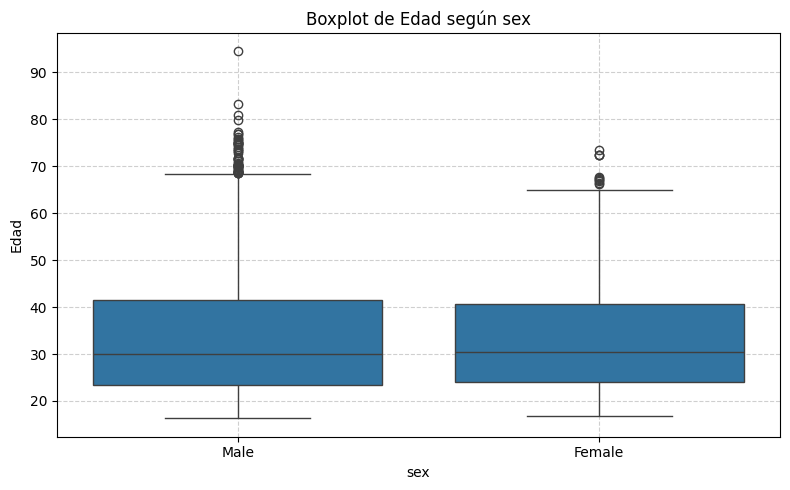

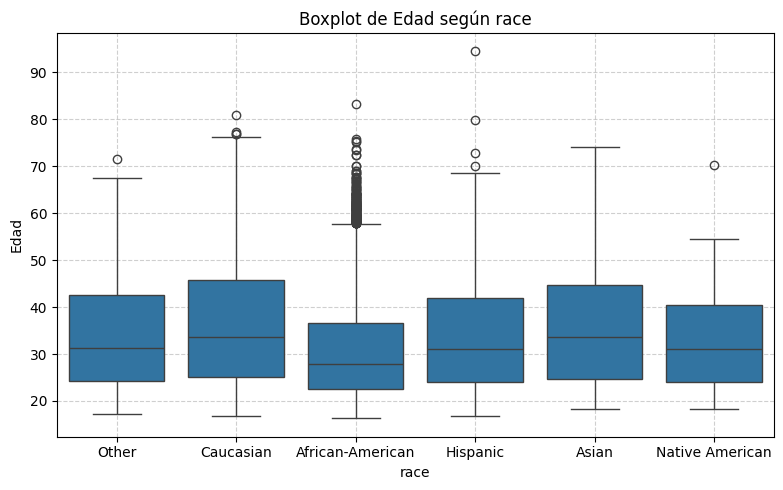

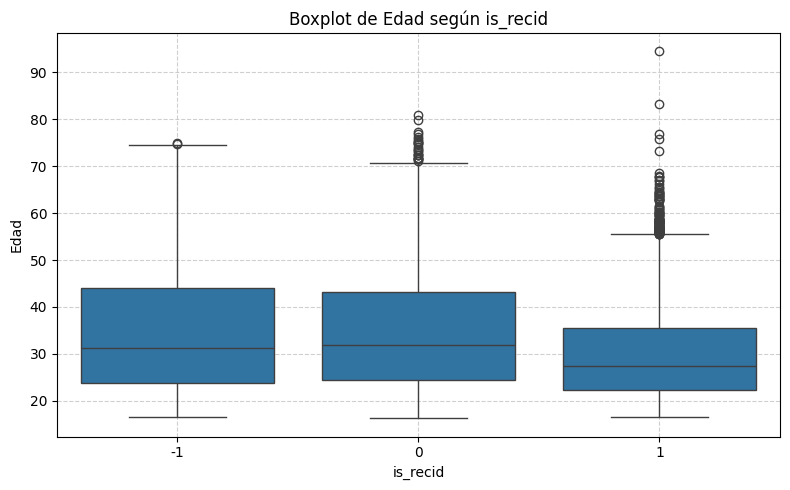

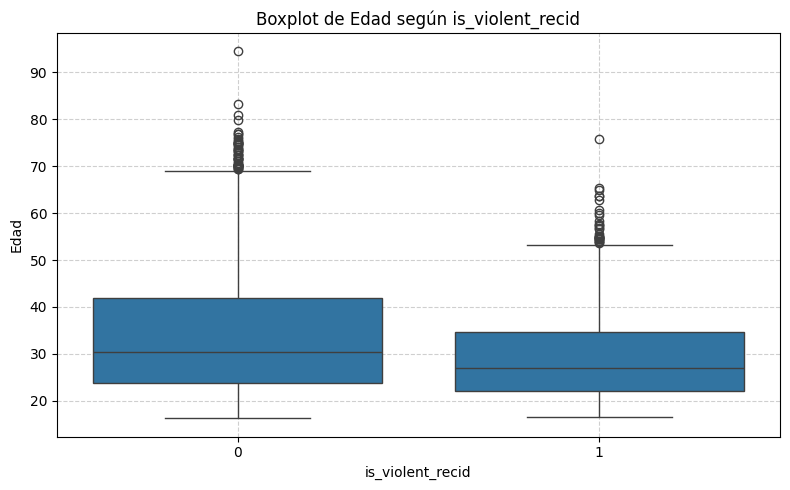

In [17]:
# Variables categóricas a comparar con edad
variables_categoricas = ['sex', 'race', 'is_recid', 'is_violent_recid']

# Crear un boxplot para cada variable categórica vs. edad
for var in variables_categoricas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_compas, x=var, y='edad')
    plt.title(f'Boxplot de Edad según {var}')
    plt.xlabel(var)
    plt.ylabel('Edad')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [18]:
df_compas.head()

,id,name,first,last,compas_screening_date,sex,dob,edad_declarada,edad,age_cat,...,v_decile_score,v_score_text,v_score_ord,v_screening_date,type_of_assessment,decile_score.1,score_text,screening_date,reincidencia_2anios,reincidencia_violenta_2anios
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,66.3,Greater than 45,...,1,Low,1,2013-08-14,Risk of Recidivism,1,Low,2013-08-14,0,0
1,2,michael ryan,michael,ryan,2014-12-31,Male,1985-02-06,31,29.9,25 - 45,...,2,Low,1,2014-12-31,Risk of Recidivism,5,Medium,2014-12-31,0,0
2,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,31.0,25 - 45,...,1,Low,1,2013-01-27,Risk of Recidivism,3,Low,2013-01-27,1,1
3,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,21.9,Less than 25,...,3,Low,1,2013-04-14,Risk of Recidivism,4,Low,2013-04-14,1,0
4,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,20.0,Less than 25,...,6,Medium,2,2013-01-13,Risk of Recidivism,8,High,2013-01-13,0,0


## 3. El umbral para establecer medidas preventivas de la reincidencia es de 7 en adelante. Dado este umbral, generar una tabla de contingencia, explicando qué caso se considera como “positivo” (y, por lo tanto, cuáles son los errores de tipo I y los errores de tipo II)

Usamos la función 'confusion_matrix' de la librería 'sklearn'

#### Tabla de contingencia Delitos Generales

In [19]:
# Asegurar formato de fechas en df_compas
df_compas['compas_screening_date'] = pd.to_datetime(df_compas['compas_screening_date'], errors='coerce')
df_compas['r_offense_date'] = pd.to_datetime(df_compas['r_offense_date'], errors='coerce')

# Calcular diferencia en días entre fechas
df_compas['dias_hasta_reincidencia'] = (df_compas['r_offense_date'] - df_compas['compas_screening_date']).dt.days

# Crear la variable binaria de reincidencia en 2 años
df_compas['reincidencia_2anios'] = ((df_compas['dias_hasta_reincidencia'] >= 0) & 
                                    (df_compas['dias_hasta_reincidencia'] <= 730)).astype(int)

# Predicción del sistema: alto riesgo si decile_score >= 7
df_compas['compas_predicho_alto_umbral7'] = (df_compas['decile_score'] >= 7).astype(int)

# Variables para la matriz de confusión
y_true = df_compas['reincidencia_2anios']
y_pred = df_compas['compas_predicho_alto_umbral7']

# Matriz de confusión
conf_matrix = confusion_matrix(y_true, y_pred)

# Crear tabla de contingencia
tabla_contingencia = pd.DataFrame(conf_matrix,
                                  index=["No reincide (Real)", "Reincide (Real)"],
                                  columns=["No Riesgo (Predicho)", "Alto Riesgo (Predicho)"])

# Mostrar resultados
print("\nTabla de contingencia (umbral ≥ 7):")
print(tabla_contingencia)

print("""
Interpretación:
- Positivo: COMPAS predice 'Alto Riesgo' (decile_score ≥ 7)
- Negativo: COMPAS predice 'No Riesgo' (decile_score < 7)
- Falsos Positivos (Error Tipo I): Personas sin reincidencia que COMPAS marcó como alto riesgo.
- Falsos Negativos (Error Tipo II): Personas reincidentes que COMPAS marcó como bajo riesgo.
""")


Tabla de contingencia (umbral ≥ 7):
                    No Riesgo (Predicho)  Alto Riesgo (Predicho)
No reincide (Real)                  6628                    1704
Reincide (Real)                     2021                    1404

Interpretación:
- Positivo: COMPAS predice 'Alto Riesgo' (decile_score ≥ 7)
- Negativo: COMPAS predice 'No Riesgo' (decile_score < 7)
- Falsos Positivos (Error Tipo I): Personas sin reincidencia que COMPAS marcó como alto riesgo.
- Falsos Negativos (Error Tipo II): Personas reincidentes que COMPAS marcó como bajo riesgo.



🔍 Classification Report - Reincidencia (umbral ≥ 7):

              precision    recall  f1-score   support

 No reincide       0.77      0.80      0.78      8332
    Reincide       0.45      0.41      0.43      3425

    accuracy                           0.68     11757
   macro avg       0.61      0.60      0.61     11757
weighted avg       0.67      0.68      0.68     11757



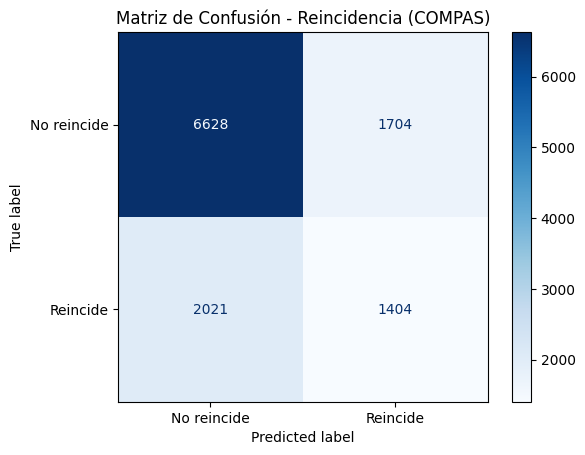

In [20]:
# Variables verdaderas y predichas
y_true_gen = df_compas['reincidencia_2anios']
y_pred_gen = df_compas['compas_predicho_alto_umbral7']

# Mostrar clasificación report
print("🔍 Classification Report - Reincidencia (umbral ≥ 7):\n")
print(classification_report(y_true_gen, y_pred_gen, target_names=["No reincide", "Reincide"]))

# Mostrar matriz de confusión visual
cm = confusion_matrix(y_true_gen, y_pred_gen)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No reincide", "Reincide"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Reincidencia (COMPAS)")
plt.grid(False)
plt.show()

El error de tipo 1, con 2021 casos que se han definido por el algoritmo como 'No Riesgo' representan un elevado porcentaje de error en la predicción. Se obtienen 1704 casos de error tipo 2. 
En este caso podemos considerar que es más peligroso o arriesgado no hacer seguimiento a reincidentes con una valoración de 'No riesgo', que a los casos predichos de alto riesgo que no han cometido delitos, ya que no sabemos a ciencia cierta si no los han cometido o no se han detectado. 

#### Tabla de contingencia Delitos Violentos

In [21]:
# Asegurar formato correcto de fechas
df_compas['vr_offense_date'] = pd.to_datetime(df_compas['vr_offense_date'], errors='coerce')
df_compas['compas_screening_date'] = pd.to_datetime(df_compas['compas_screening_date'], errors='coerce')

# Calcular diferencia de días entre screening y delito violento
df_compas['dias_hasta_reincidencia_violenta'] = (df_compas['vr_offense_date'] - df_compas['compas_screening_date']).dt.days

# Crear variable binaria para reincidencia violenta en 2 años
df_compas['reincidencia_violenta_2anios'] = ((df_compas['dias_hasta_reincidencia_violenta'] >= 0) & 
                                             (df_compas['dias_hasta_reincidencia_violenta'] <= 730)).astype(int)

# Predicción de COMPAS (ya calculada anteriormente)
# df_compas['compas_predicho_alto_umbral7'] = (df_compas['decile_score'] >= 7).astype(int)

# Variables para matriz de confusión violenta
y_true_violenta = df_compas['reincidencia_violenta_2anios']
y_pred = df_compas['compas_predicho_alto_umbral7']

# Matriz de confusión
from sklearn.metrics import confusion_matrix
conf_matrix_violenta = confusion_matrix(y_true_violenta, y_pred)

# Tabla de contingencia
tabla_contingencia_violenta = pd.DataFrame(conf_matrix_violenta,
                                           index=["No reincide violentamente (Real)", "Reincide violentamente (Real)"],
                                           columns=["No Riesgo (Predicho)", "Alto Riesgo (Predicho)"])

# Mostrar resultados
print("\nTabla de contingencia - Reincidencia violenta (umbral ≥ 7):")
print(tabla_contingencia_violenta)

print("""
Interpretación:
- Positivo: COMPAS predice 'Alto Riesgo'
- Negativo: COMPAS predice 'No Riesgo'
- Falsos Positivos (Error Tipo I): Personas sin reincidencia violenta marcadas como alto riesgo.
- Falsos Negativos (Error Tipo II): Personas con reincidencia violenta marcadas como bajo riesgo.
""")


Tabla de contingencia - Reincidencia violenta (umbral ≥ 7):
                                  No Riesgo (Predicho)  Alto Riesgo (Predicho)
No reincide violentamente (Real)                  8243                    2745
Reincide violentamente (Real)                      406                     363

Interpretación:
- Positivo: COMPAS predice 'Alto Riesgo'
- Negativo: COMPAS predice 'No Riesgo'
- Falsos Positivos (Error Tipo I): Personas sin reincidencia violenta marcadas como alto riesgo.
- Falsos Negativos (Error Tipo II): Personas con reincidencia violenta marcadas como bajo riesgo.



🔍 Classification Report - Reincidencia Violenta (umbral ≥ 7):

              precision    recall  f1-score   support

 No reincide       0.95      0.75      0.84     10988
    Reincide       0.12      0.47      0.19       769

    accuracy                           0.73     11757
   macro avg       0.53      0.61      0.51     11757
weighted avg       0.90      0.73      0.80     11757



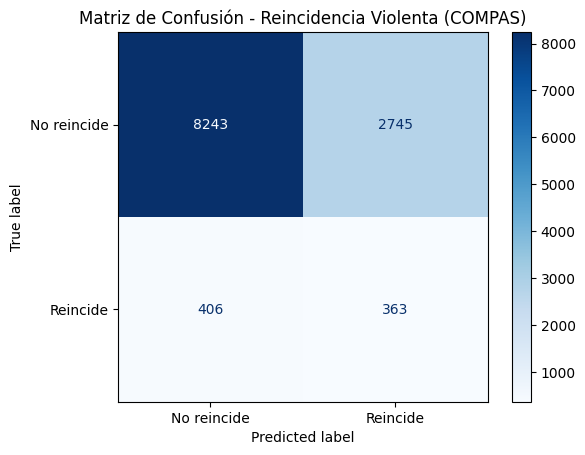

In [22]:
# Variables verdaderas y predichas
y_true_violencia = df_compas['reincidencia_violenta_2anios']
y_pred_violencia = df_compas['compas_predicho_alto_umbral7']

# Mostrar clasificación report
print("🔍 Classification Report - Reincidencia Violenta (umbral ≥ 7):\n")
print(classification_report(y_true_violencia, y_pred_violencia, target_names=["No reincide", "Reincide"]))

# Mostrar matriz de confusión visual
cm = confusion_matrix(y_true_violencia, y_pred_violencia)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No reincide", "Reincide"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Reincidencia Violenta (COMPAS)")
plt.grid(False)
plt.show()

El error de tipo 1, con 406 casos que se han definido por el algoritmo como 'No Riesgo' representan un elevado porcentaje de error en la predicción. Se obtienen 2745 casos de error tipo 2. 
En este caso podemos considerar que es más peligroso o arriesgado no hacer seguimiento a reincidentes con una valoración de 'No riesgo', que a los casos predichos de alto riesgo que no han cometido delitos, ya que no sabemos a ciencia cierta si no los han cometido o no se han detectado. 

## * 4 - El sistema asigna, de media, evaluaciones de riesgo más altas a los hombres que a las mujeres, y a las personas de raza afroamericana que a las de raza caucásica. Sin embargo, también las tasas de reincidencia son más altas para esos colectivos, aunque no está claro que la asignación de riesgo sea “justa” o no. Mostrar estas diferencias mediante representaciones gráficas y utilizarlas para analizar si la asignación de evaluaciones es justa o no.

### Visualizaciones

4 - El sistema asigna, de media, evaluaciones de riesgo más altas a los hombres que a las mujeres, y a las
personas de raza afroamericana que a las de raza caucásica. Sin embargo, también las tasas de reincidencia
son más altas para esos colectivos, aunque no está claro que la asignación de riesgo sea “justa” o no. Mostrar
estas diferencias mediante representaciones gráficas y utilizarlas para analizar si la asignación de
evaluaciones es justa o no

A continuación vamos a hacer una exploración visual de los datos para detectar patrones o anomalías

#### Reparto de los delitos por razas

📊 Distribución de la variable 'raza':


,Frecuencia,Porcentaje (%)
race,,
African-American,5813,49.44
Caucasian,4085,34.75
Hispanic,1100,9.36
Other,661,5.62
Asian,58,0.49
Native American,40,0.34


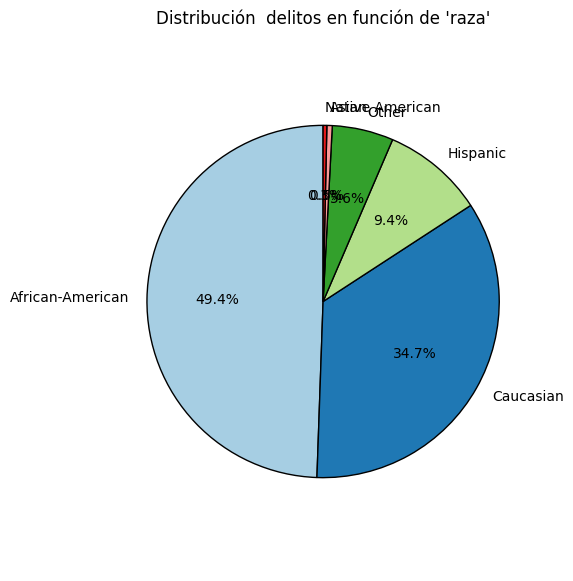

In [23]:
# Recuento absoluto y porcentual
race_counts = df["race"].value_counts(dropna=False)
race_percent = (race_counts / len(df) * 100).round(2)

# Crear tabla resumen
tabla_race = pd.DataFrame({
    "Frecuencia": race_counts,
    "Porcentaje (%)": race_percent
})

print("📊 Distribución de la variable 'raza':")
display(tabla_race)

# Calcular distribución
race_counts = df["race"].value_counts(dropna=False)

# Crear gráfico de tarta
plt.figure(figsize=(5,7))
plt.pie(
    race_counts,
    labels=race_counts.index,
    autopct='%1.1f%%',      # mostrar porcentajes con un decimal
    startangle=90,          # empezar desde arriba
    colors=plt.cm.Paired.colors,  # paleta de colores equilibrada
    wedgeprops={'edgecolor': 'black'}
)
plt.title("Distribución  delitos en función de 'raza'")
plt.axis('equal')  # mantener la proporción circular
plt.show()

#### Reparto de los delitos por Sexos

📊 Distribución de la variable 'sex':


,Frecuencia,Porcentaje (%)
sex,,
Male,9336,79.41
Female,2421,20.59


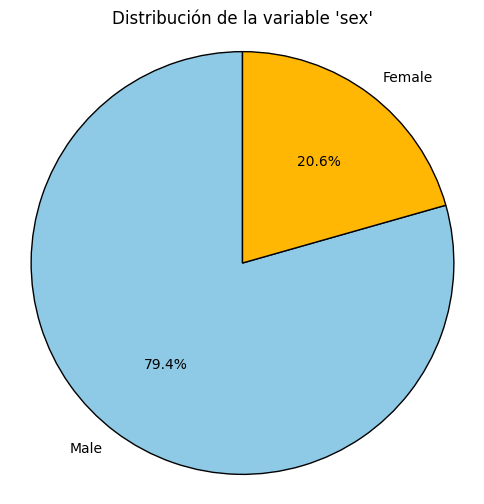

In [24]:
# Recuento absoluto y porcentual
sex_counts = df["sex"].value_counts(dropna=False)
sex_percent = (sex_counts / len(df) * 100).round(2)

# Crear tabla resumen
tabla_sex = pd.DataFrame({
    "Frecuencia": sex_counts,
    "Porcentaje (%)": sex_percent
})

print("📊 Distribución de la variable 'sex':")
display(tabla_sex)

# Gráfico de tarta
plt.figure(figsize=(6,6))
plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct='%1.1f%%',        # mostrar porcentaje con 1 decimal
    startangle=90,            # comenzar desde arriba
    colors=["#8ecae6", "#ffb703"],  # paleta suave (azul y naranja)
    wedgeprops={'edgecolor': 'black'}
)
plt.title("Distribución de la variable 'sex'")
plt.axis('equal')  # mantener forma circular
plt.show()

#### Comparativa columnas de fechas para delitos generales, delitos violentos y COMPAS_screening

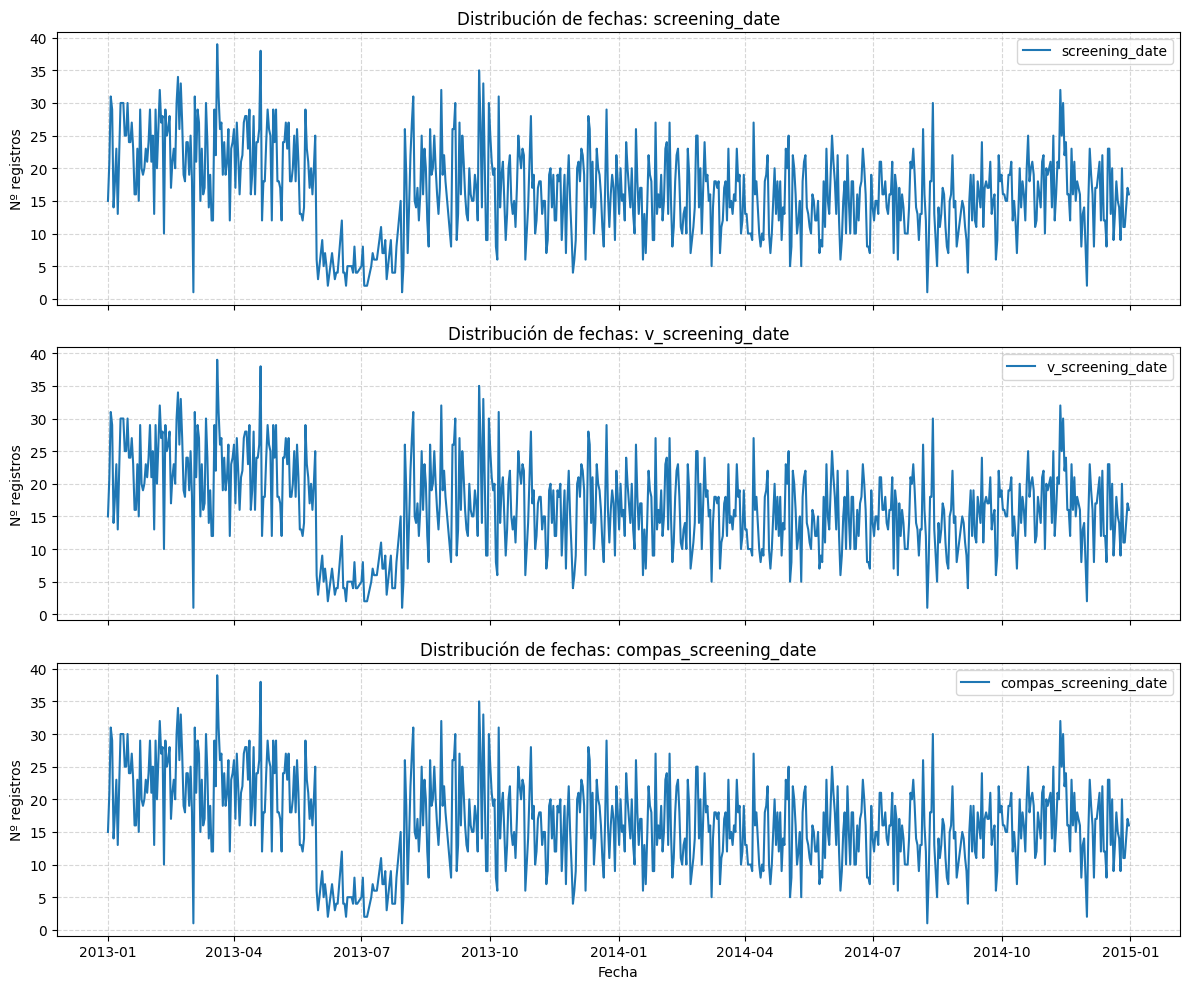

In [25]:
# Convertimos columnas a datetime si no lo están
for col in ['screening_date', 'v_screening_date', 'compas_screening_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Contamos registros por fecha para cada columna
conteos = {}
for col in ['screening_date', 'v_screening_date', 'compas_screening_date']:
    fechas = df[col].dropna().value_counts().sort_index()
    conteos[col] = fechas

# Creamos figura con 3 subplots (trellis chart)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Graficamos cada conjunto de fechas
for ax, (col, serie) in zip(axes, conteos.items()):
    ax.plot(serie.index, serie.values, label=col, color="#1f77b4")
    ax.set_title(f"Distribución de fechas: {col}")
    ax.set_ylabel("Nº registros")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

# Ajustar ejes y mostrar
plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

Las representaciones gráficas de 'screening_date', 'v_screening_date' y 'compas_screening_date' son la misma, lo que denota una clara correlación, demasiada evidente como para determinar que podría haber errores en los datos

#### Delitos violentos por fechas

/var/folders/4m/2vtc7lzd31711ffffgzw_mhc0000gn/T/ipykernel_49152/4122554168.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["vr_offense_date"] = pd.to_datetime(df["vr_offense_date"], errors="coerce")


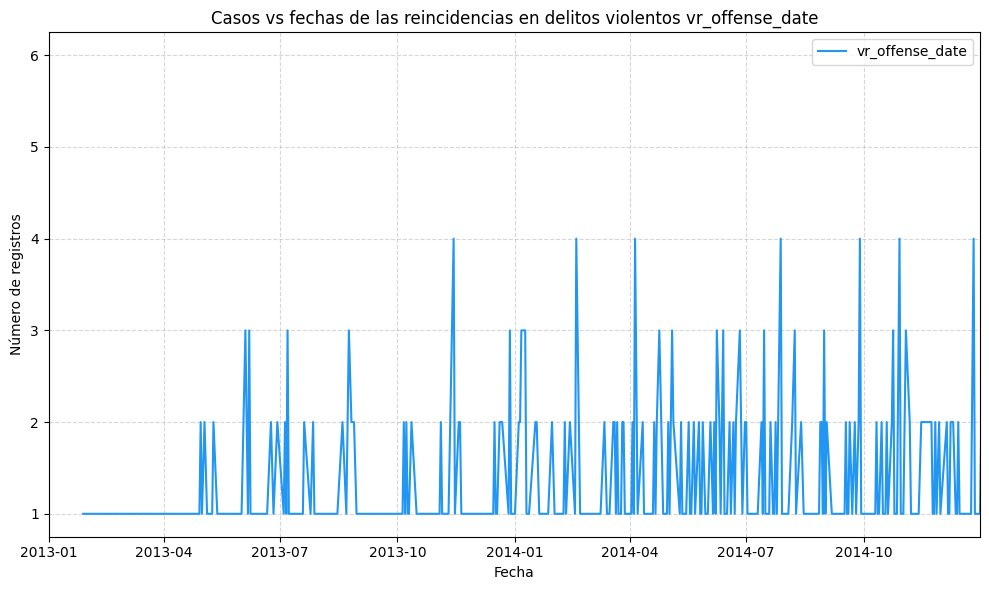

In [26]:
# Nos aseguramos que la columna esté en formato datetime
df["vr_offense_date"] = pd.to_datetime(df["vr_offense_date"], errors="coerce")

# Contamos número de registros por fecha, asegurando índice datetime
conteo_fechas = df["vr_offense_date"].dropna().value_counts().sort_index()
df_fechas = pd.DataFrame({"vr_offense_date": conteo_fechas})
df_fechas.index = pd.to_datetime(df_fechas.index)  # Asegurar tipo datetime en el índice

# Creamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(df_fechas.index, df_fechas["vr_offense_date"], label="vr_offense_date", color="#2196F3")

# Establecemos límites de X
plt.xlim(pd.to_datetime("2013-01-01"), pd.to_datetime("2014-12-31"))

# Detalles del gráfico
plt.title("Casos vs fechas de las reincidencias en delitos violentos vr_offense_date")
plt.xlabel("Fecha")
plt.ylabel("Número de registros")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### Distribución por edades

Creamos un gráfico para ver la __distribución por edades__ de los sujetos con delitos

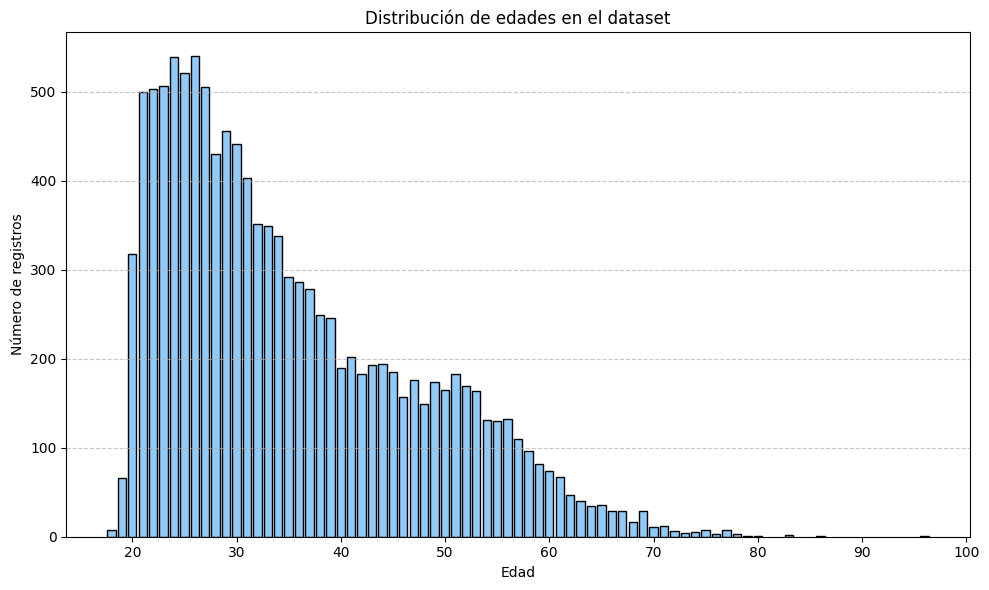

In [27]:
# Recuento de valores de edad
age_counts = df["edad_declarada"].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=(10,6))
plt.bar(age_counts.index, age_counts.values, color="#90CAF9", edgecolor="black")

plt.title("Distribución de edades en el dataset")
plt.xlabel("Edad")
plt.ylabel("Número de registros")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Discretizamos por bloque de edades para conocer la distribución por estas de los individuos registrados en el sistema

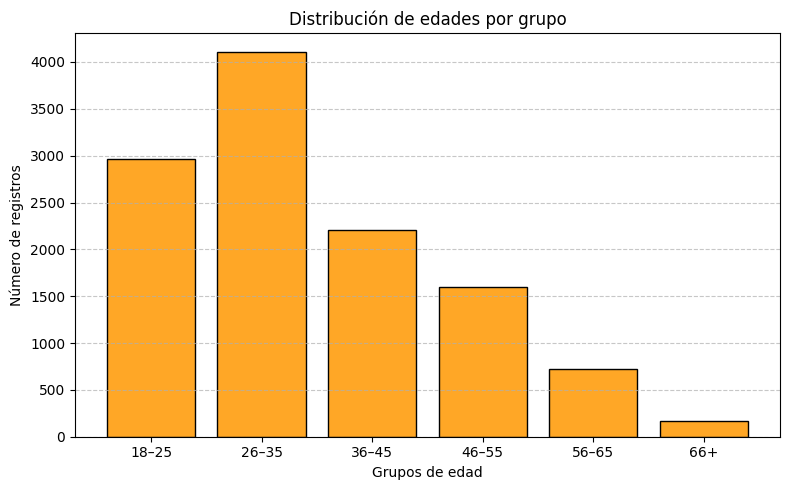

In [28]:
# Agrupar por intervalos
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "66+"]
df["age_group"] = pd.cut(df["edad_declarada"], bins=bins, labels=labels, right=True)

# Contar y graficar
age_group_counts = df["age_group"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(age_group_counts.index, age_group_counts.values, color="#FFA726", edgecolor="black")
plt.title("Distribución de edades por grupo")
plt.xlabel("Grupos de edad")
plt.ylabel("Número de registros")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Vamos a comprobar la distribución por edades de los individuos que reinciden en el marco de dos años con delitos sin violencia

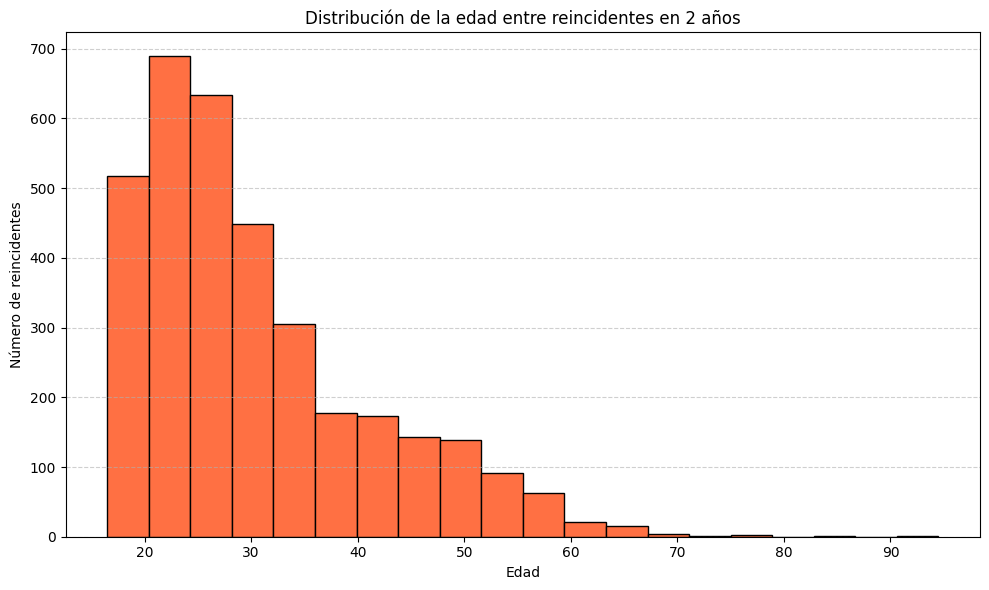

In [29]:
# Filtrar solo reincidentes
df_reincidentes = df_compas[df_compas['reincidencia_2anios'] == 1]

# Crear histograma
plt.figure(figsize=(10, 6))
plt.hist(df_reincidentes['edad'].dropna(), bins=20, color="#FF7043", edgecolor='black')

# Personalizar gráfico
plt.title("Distribución de la edad entre reincidentes en 2 años")
plt.xlabel("Edad")
plt.ylabel("Número de reincidentes")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Vamos a comprobar la distribución por edades de los individuos que reinciden en el marco temporal de dos años con delitos con violencia

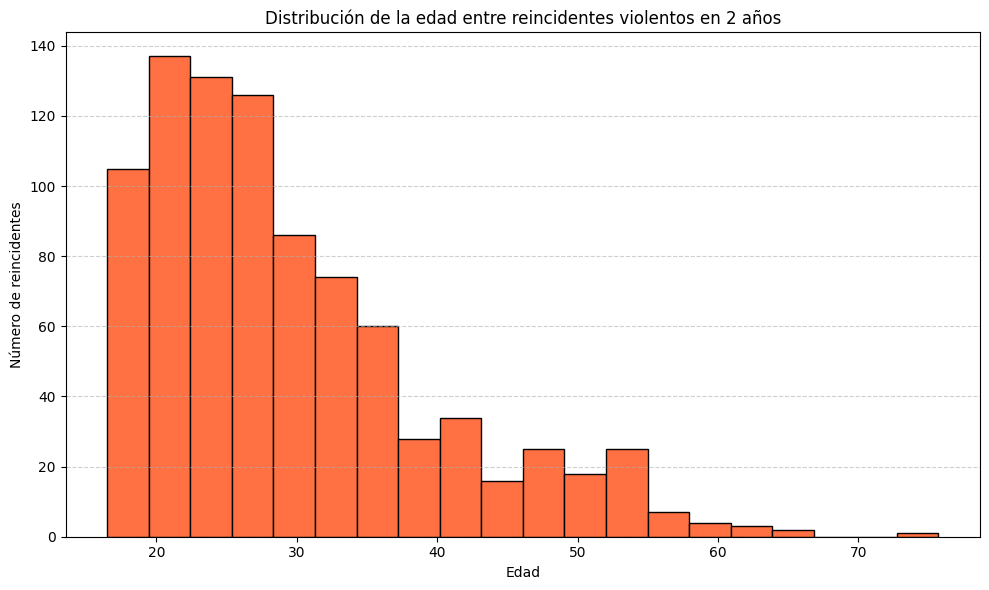

In [30]:
# Filtrar solo reincidentes violentos
df_reincidentes2 = df_compas[df_compas['is_violent_recid'] == 1]

# Crear histograma
plt.figure(figsize=(10, 6))
plt.hist(df_reincidentes2['edad'].dropna(), bins=20, color="#FF7043", edgecolor='black')

# Personalizar gráfico
plt.title("Distribución de la edad entre reincidentes violentos en 2 años")
plt.xlabel("Edad")
plt.ylabel("Número de reincidentes")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Distribución por razas y edades

Visualizamos la distribución por edades en función de las razas con columnas apiladas

<Figure size 1000x600 with 0 Axes>

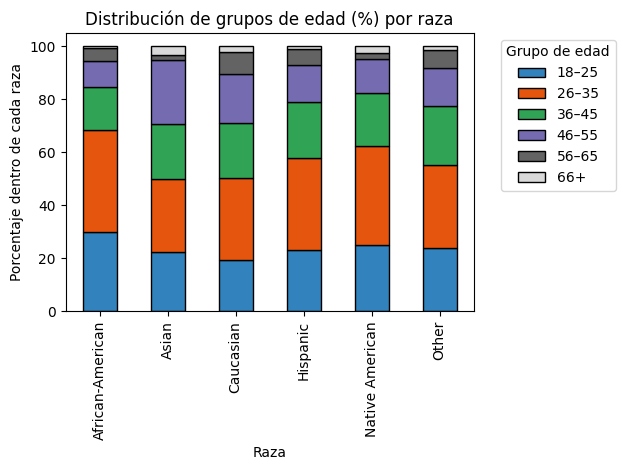

In [31]:
# Asegurarnos de que existe la variable de grupos de edad (como la del ejemplo anterior)
df["age_group"] = pd.cut(df["edad_declarada"], bins=bins, labels=labels, right=True)

# Crear tabla cruzada (race vs grupo de edad)
tabla_age_race = pd.crosstab(df["race"], df["age_group"], normalize='index') * 100

# --- Gráfico ---
plt.figure(figsize=(10,6))
tabla_age_race.plot(kind='bar', stacked=True, colormap='tab20c', edgecolor='black')

plt.title("Distribución de grupos de edad (%) por raza")
plt.xlabel("Raza")
plt.ylabel("Porcentaje dentro de cada raza")
plt.legend(title="Grupo de edad", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Observamos porcentajes hombres/mujeres en función de la raza, mostrando una tabla que especifica los porcentajes y un gráfico de columnas apiladas

📊 Distribución porcentual de 'sex' dentro de cada grupo de 'race':


sex,Female,Male
race,,
African-American,19.20,80.80
Asian,12.07,87.93
Caucasian,23.70,76.30
Hispanic,17.18,82.82
Native American,25.00,75.00
Other,19.82,80.18


<Figure size 800x600 with 0 Axes>

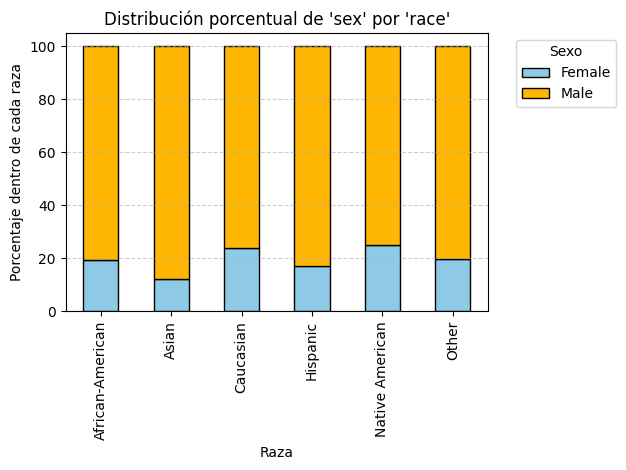

In [32]:
# Crear tabla cruzada (conteo y porcentaje)
tabla_race_sex = pd.crosstab(df["race"], df["sex"], normalize='index') * 100

print("📊 Distribución porcentual de 'sex' dentro de cada grupo de 'race':")
display(tabla_race_sex.round(2))

# --- Gráfico de barras apiladas ---
plt.figure(figsize=(8,6))
tabla_race_sex.plot(kind='bar', stacked=True, color=["#8ecae6", "#ffb703"], edgecolor='black')

plt.title("Distribución porcentual de 'sex' por 'race'")
plt.xlabel("Raza")
plt.ylabel("Porcentaje dentro de cada raza")
plt.legend(title="Sexo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Con la librería __Seaborn__, facetamos por razas, sexo y número de registros

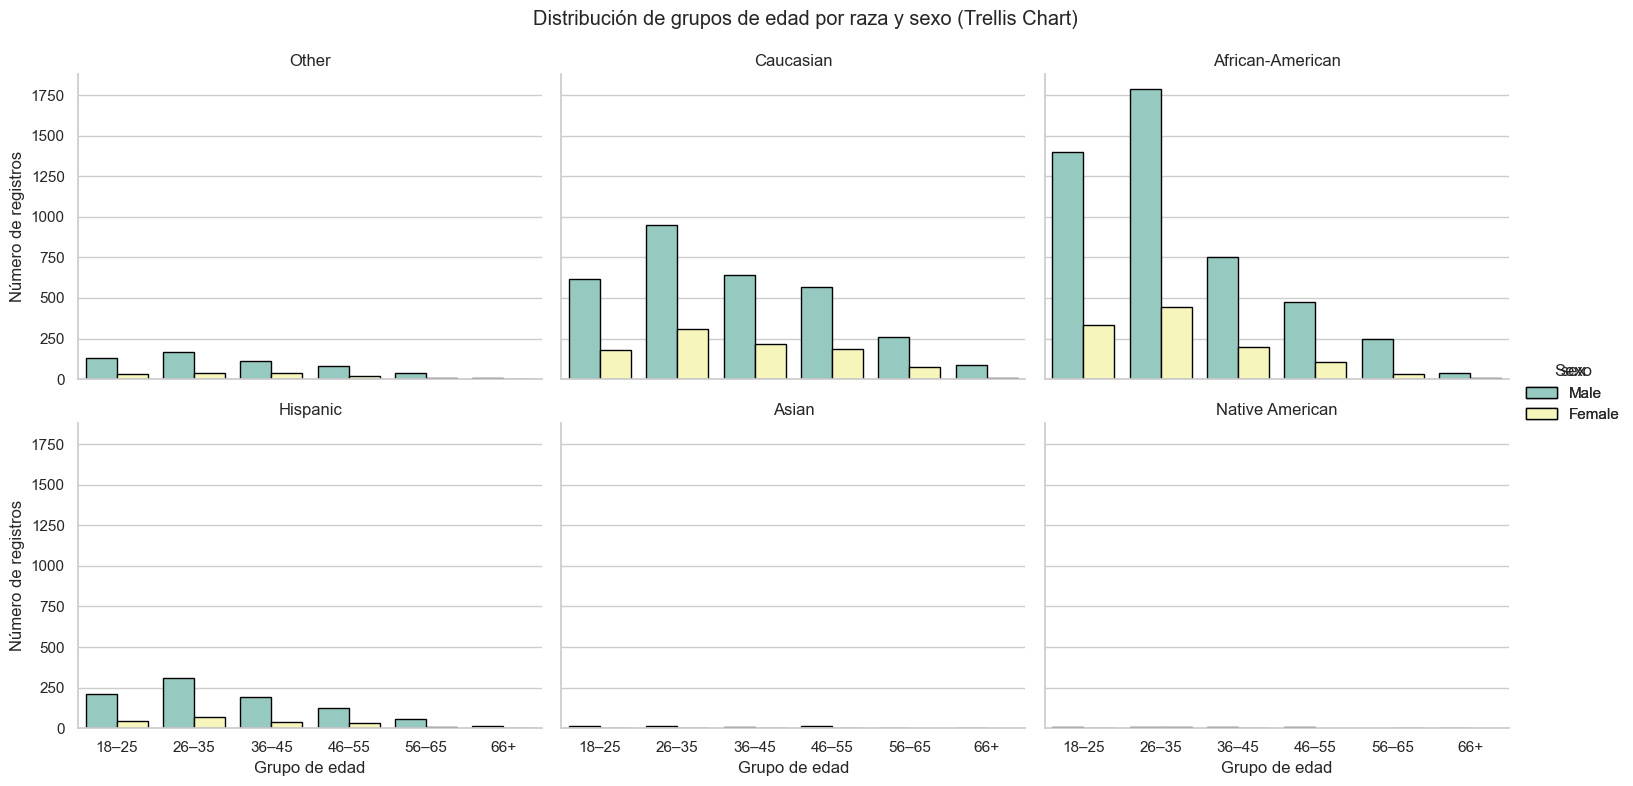

In [33]:
# Configuramos el estilo del gráfico
sns.set(style="whitegrid")

# Crear el Trellis chart (FacetGrid)
g = sns.catplot(
    data=df,
    kind="count",
    x="age_group",
    hue="sex",
    col="race",
    col_wrap=3,          
    palette="Set3",      
    edgecolor="black",
    height=4,            
    aspect=1.2           
)

# Ajustes del gráfico
g.set_titles("{col_name}")  # título de cada subgráfico (raza)
g.set_axis_labels("Grupo de edad", "Número de registros")
g.add_legend(title="Sexo")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribución de grupos de edad por raza y sexo (Trellis Chart)")
plt.show()

El sesgo de COMPAS tiene sentido debido a la representación de los tipos de registro o individuos que suelen cometer delitos con y sin violencia. Algo que en casos anómalos, no sería de utilidad, es decir, para casos de delincuentes que no tengan un corportamiento que esté reflejado en la distribución, no se podría predecir su probabilidad de reincidencia y quedar fuea del seguimiento para medidas preventivas. 

Para declarar como justa o no las evaluaciones del modelo, habría que acceder a marcos temporales más amplios, asegurarse que los registros tienen un alto grado de fiabilidad en relación a la comisión de los delitos y son registrados adecuadamente. 

## 5 - ¿Para qué tipo de riesgos, el de delitos generales o el de delitos violentos, tiene el sistema más capacidad predictiva?

#### Delitos generales

Según la tabla de contingencia de delitos generales que hemos ejecutado con el modelo:

	•	VP (Verdaderos Positivos): 1.404
	•	VN (Verdaderos Negativos): 6.628
	•	FP (Falsos Positivos): 1.704
	•	FN (Falsos Negativos): 2.021


Esto nos da para riesgo general:

Precision = {VP}/{VP + FP} = {1404}/{1404 + 1704} = 0.452

Recall = {VP}/{VP + FN} = {1404}/{1404 + 2021} = 0.41

Accuracy = {VP + VN}/{Total} = {1404 + 6628}/{11757} = 0.68

F.score = 2 ({Precision * Recall} / {Precision + Recall} = 0.43

__Conclusiones de los delitos generales__

	•	Hay demasiados falsos positivos, que pueden llevar a decisiones judiciales injustas.
	•	Se escapan muchos reincidentes reales, lo que compromete la utilidad del sistema.
	•	La precisión y el recall están muy por debajo del nivel deseable en aplicaciones con implicaciones éticas y legales tan serias.

COMPAS no muestra una capacidad predictiva suficientemente fiable para reincidencia general.

#### Delitos violentos

Según la tabla de contingencia de delitos violentos que hemos ejecutado con el modelo:

	•	VP (Verdaderos Positivos): 363
	•	VN (Verdaderos Negativos): 8.243
	•	FP (Falsos Positivos): 2.745
	•	FN (Falsos Negativos): 406
 

Esto nos da para riesgo de delitos violentos:

Precision = {TP}/{TP + FP} ={363}/{363 + 2745} = 0.117

Recall= {TP}/{TP + FN} = {363}/{363 + 406} = 0.472

Accuracy = {TP + TN}/{TP + TN + FP + FN} = {363 + 8243}/{8243 + 2745 + 406 + 363} = 0.768

F.Score} = 2 * ({Precision * Recall}/{Precision + Recall}) ≈ 0.187


COMPAS tiene alta exactitud o accuracy pero eso se debe a que la mayoría no reinciden. 

COMPAS solo identfica correctamente al 47% de los reincidentes violentos

De todos los que el sistema marco como "alto riesgo violento", solo el 11.7% realmente reinciden o se tiene constancia de ello

F.score indica un mal equilibrio entre precisión y recall

Por lo tanto, el sistema COMPAS falla mucho prediciendo la reincidencia violenta, con poca capacidad predictiva rela y generando muchos falsos positivos, lo que provocaría un seguimiento a individuos que finalmente no comenterían un delito similar. 

COMPAS falla mucho más prediciendo reincidencia violenta que reincidencia general:

	•	Tiene poca capacidad predictiva real para violencia.
	•	Genera muchos falsos positivos (personas etiquetadas injustamente como peligrosas).
 

Eso nos dice que hay mayor interés por predecir y prescribir acciones a fin de prevenir delitos violentos que los delitos generales

## Análisis Final

#### Evaluación general del sistema COMPAS

Tras evaluar las predicciones para reincidencia general y reincidencia violenta, se observan claras limitaciones en la capacidad predictiva del sistema, especialmente en cuanto a falsos positivos.

---

#### Comparativa de métricas (Umbral ≥ 7)

| Métrica        | Reincidencia General | Reincidencia Violenta |
|----------------|----------------------|------------------------|
| **Precisión**  | 0.452                | 0.117                 |
| **Recall**     | 0.410                | 0.472                 |
| **Accuracy**   | 0.68                 | 0.768                 |
| **F1 Score**   | 0.43                 | 0.187                 |




#### Interpretación numérica de las métricas

A continuación interpretamos en términos comprensibles los valores obtenidos para las métricas de precisión, recall y F1 en el análisis de reincidencia:

- **Precisión (Reincidencia General ≈ 31%)**:
  > De todas las personas que COMPAS predijo como de "alto riesgo", solo el **31% realmente reincidió**. Esto implica un **69% de falsos positivos**, lo que puede representar una injusticia al sobreestimar el riesgo en muchos casos.

- **Recall (Reincidencia Violenta ≈ 47%)**:
  > COMPAS detecta correctamente al **47% de las personas que reinciden con violencia**, pero **pierde al 53%** de reincidentes reales, lo cual es crítico si el objetivo es prevenir delitos futuros peligrosos.

- **F1 Score**:
  > Combina precisión y recall. En ambos tipos de reincidencia, el F1 se encuentra en valores moderadamente bajos, indicando que el sistema tiene limitaciones tanto para identificar reincidentes como para evitar alarmas injustificadas.

Estas cifras muestran que **la capacidad predictiva del sistema es limitada**, especialmente en el ámbito de los delitos violentos, donde un alto número de reincidentes no son correctamente anticipados.

#### Comparativa gráfica de métricas: Reincidencia general vs violenta

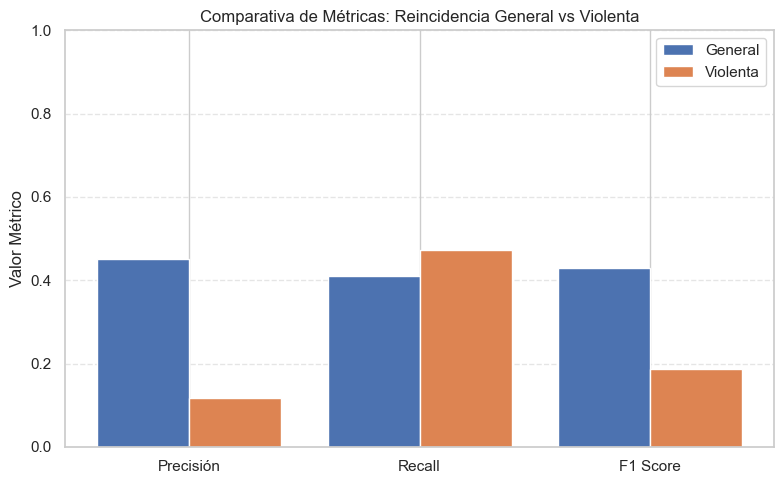

In [34]:
# General
precision_general = precision_score(df_compas['reincidencia_2anios'], df_compas['compas_predicho_alto_umbral7'])
recall_general = recall_score(df_compas['reincidencia_2anios'], df_compas['compas_predicho_alto_umbral7'])
f1_general = f1_score(df_compas['reincidencia_2anios'], df_compas['compas_predicho_alto_umbral7'])

# Violenta
precision_violenta = precision_score(df_compas['reincidencia_violenta_2anios'], df_compas['compas_predicho_alto_umbral7'])
recall_violenta = recall_score(df_compas['reincidencia_violenta_2anios'], df_compas['compas_predicho_alto_umbral7'])
f1_violenta = f1_score(df_compas['reincidencia_violenta_2anios'], df_compas['compas_predicho_alto_umbral7'])

labels = ['Precisión', 'Recall', 'F1 Score']
general = [precision_general, recall_general, f1_general]
violenta = [precision_violenta, recall_violenta, f1_violenta]

x = range(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x, general, width=0.4, label='General', align='center')
plt.bar([p + 0.4 for p in x], violenta, width=0.4, label='Violenta', align='center')
plt.xticks([p + 0.2 for p in x], labels)
plt.ylim(0, 1)
plt.title("Comparativa de Métricas: Reincidencia General vs Violenta")
plt.ylabel("Valor Métrico")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---

### Conclusiones:

- COMPAS **predice mejor la reincidencia general que la violenta**, pero aún así **presenta una elevada tasa de falsos positivos**.
- En el caso de violencia, **muchos individuos no reincidentes son etiquetados como de alto riesgo** (precisión muy baja).
- La exactitud (accuracy) puede ser engañosa debido al **desequilibrio en las clases** (pocos reincidentes frente a muchos no reincidentes).
- Es crucial considerar estas métricas antes de usar un sistema así en decisiones judiciales, debido al **riesgo ético y social** de errores tipo I.

---